In [2]:
!pip install -q ultralytics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.2 MB/s eta 0:00:00


In [13]:
import os
import cv2
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

In [14]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [15]:
DATASET_ROOT = "/kaggle/input/datasets/kaggleprollc/mapillary-vistas-image-data-collection/Mapillary Vistas"

TRAIN_IMAGES = f"{DATASET_ROOT}/training/images"
TRAIN_LABELS = f"{DATASET_ROOT}/training/v1.2/labels"

VAL_IMAGES = f"{DATASET_ROOT}/validation/images"
VAL_LABELS = f"{DATASET_ROOT}/validation/v1.2/labels"

In [16]:
print(os.listdir(DATASET_ROOT))

['config_v1.2.json', 'validation', 'README', 'training', 'testing', 'config_v2.0.json']


In [18]:
import shutil
import os

#shutil.rmtree("/kaggle/working/yolo_dataset")

os.makedirs("/kaggle/working/yolo_dataset/images/train", exist_ok=True)
os.makedirs("/kaggle/working/yolo_dataset/images/val", exist_ok=True)

os.makedirs("/kaggle/working/yolo_dataset/labels/train", exist_ok=True)
os.makedirs("/kaggle/working/yolo_dataset/labels/val", exist_ok=True)

In [19]:
with open(f"{DATASET_ROOT}/config_v1.2.json", "r") as f:
    config = json.load(f)

labels = config["labels"]

for i, label in enumerate(labels):
    print(i, "->", label["readable"])

0 -> Bird
1 -> Ground Animal
2 -> Curb
3 -> Fence
4 -> Guard Rail
5 -> Barrier
6 -> Wall
7 -> Bike Lane
8 -> Crosswalk - Plain
9 -> Curb Cut
10 -> Parking
11 -> Pedestrian Area
12 -> Rail Track
13 -> Road
14 -> Service Lane
15 -> Sidewalk
16 -> Bridge
17 -> Building
18 -> Tunnel
19 -> Person
20 -> Bicyclist
21 -> Motorcyclist
22 -> Other Rider
23 -> Lane Marking - Crosswalk
24 -> Lane Marking - General
25 -> Mountain
26 -> Sand
27 -> Sky
28 -> Snow
29 -> Terrain
30 -> Vegetation
31 -> Water
32 -> Banner
33 -> Bench
34 -> Bike Rack
35 -> Billboard
36 -> Catch Basin
37 -> CCTV Camera
38 -> Fire Hydrant
39 -> Junction Box
40 -> Mailbox
41 -> Manhole
42 -> Phone Booth
43 -> Pothole
44 -> Street Light
45 -> Pole
46 -> Traffic Sign Frame
47 -> Utility Pole
48 -> Traffic Light
49 -> Traffic Sign (Back)
50 -> Traffic Sign (Front)
51 -> Trash Can
52 -> Bicycle
53 -> Boat
54 -> Bus
55 -> Car
56 -> Caravan
57 -> Motorcycle
58 -> On Rails
59 -> Other Vehicle
60 -> Trailer
61 -> Truck
62 -> Wheeled

In [20]:
FINAL_CLASSES = {
    "road": 0,
    "person": 1,
    "vehicle": 2,
    "bicycle": 3,
}

In [22]:
CLASS_MAP = {

    # ROAD
    13: 0,

    # PERSON
    19: 1,

    # VEHICLES
    54: 2,   # bus
    55: 2,   # car
    57: 2,   # motorcycle
    59: 2,   # other vehicle
    61: 2,   # truck

    # BICYCLE + RIDERS
    20: 3,   # bicyclist
    52: 3,   # bicycle

}

In [23]:
COLOR_MAP = {}

for old_id, new_id in CLASS_MAP.items():

    color = labels[old_id]["color"]

    COLOR_MAP[tuple(color)] = new_id

print(COLOR_MAP)

{(128, 64, 128): 0, (220, 20, 60): 1, (0, 60, 100): 2, (0, 0, 142): 2, (0, 0, 230): 2, (128, 64, 64): 2, (0, 0, 70): 2, (255, 0, 0): 3, (119, 11, 32): 3}


In [24]:
def mask_to_polygons(mask, class_id):

    binary = np.uint8(mask == class_id)

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    polygons = []

    for contour in contours:

        if len(contour) < 3:
            continue

        contour = contour.squeeze()

        if len(contour.shape) != 2:
            continue

        area = cv2.contourArea(contour)

        if area < 200:    #20
            continue

        epsilon = 0.002 * cv2.arcLength(contour, True)   #0.002

        approx = cv2.approxPolyDP(
            contour,
            epsilon,
            True
        )

        polygons.append(approx.squeeze())

    return polygons

In [26]:
def convert_split(split="training"):

    TARGET_SIZE = (1280, 960)

    if split == "training":

        image_dir = TRAIN_IMAGES
        label_dir = TRAIN_LABELS

        out_img = "/kaggle/working/yolo_dataset/images/train"
        out_lbl = "/kaggle/working/yolo_dataset/labels/train"

    else:

        image_dir = VAL_IMAGES
        label_dir = VAL_LABELS

        out_img = "/kaggle/working/yolo_dataset/images/val"
        out_lbl = "/kaggle/working/yolo_dataset/labels/val"

    images = sorted(glob(image_dir + "/*.jpg"))[:5000]

    for img_path in tqdm(images):

        name = os.path.basename(img_path).replace(".jpg", "")

        label_path = f"{label_dir}/{name}.png"

        if not os.path.exists(label_path):
            continue

#LOAD_IMAGE

        image = cv2.imread(img_path)

        image = cv2.resize(
            image,
            TARGET_SIZE,
            interpolation=cv2.INTER_AREA
        )

#LOAD_RGB_MASK

        mask_rgb = cv2.imread(label_path)

        mask_rgb = cv2.cvtColor(
            mask_rgb,
            cv2.COLOR_BGR2RGB
        )

#RESIZING_MASKS

        mask_rgb = cv2.resize(
            mask_rgb,
            TARGET_SIZE,
            interpolation=cv2.INTER_NEAREST
        )

#CREATING_CLASS_ID_MASK

        mask = np.zeros(
            (mask_rgb.shape[0], mask_rgb.shape[1]),
            dtype=np.uint8
        )

        for color, class_id in COLOR_MAP.items():

            matches = np.all(
                mask_rgb == color,
                axis=-1
            )

            mask[matches] = class_id

        h, w = mask.shape

        txt_lines = []

#POLYGON_EXTRACTION

        for class_id in np.unique(mask):

            if class_id == 0:
                continue

            polygons = mask_to_polygons(
                mask,
                class_id
            )

            for poly in polygons:

                poly = poly.astype(np.float32)

                poly[:, 0] /= w
                poly[:, 1] /= h

                poly = poly.flatten()

                if len(poly) < 6:
                    continue

                line = (
                    str(class_id)
                    + " "
                    + " ".join(map(str, poly))
                )

                txt_lines.append(line)

  #SAVE_RESIZED_IMG  

        cv2.imwrite(
            f"{out_img}/{name}.jpg",
            image
        )

#SAVE LABELS

        with open(
            f"{out_lbl}/{name}.txt",
            "w"
        ) as f:

            f.write("\n".join(txt_lines))

In [27]:
convert_split("training")
convert_split("validation")

100%|██████████| 2000/2000 [15:08<00:00,  2.20it/s]


In [28]:
from glob import glob

label_files = glob(
    "/kaggle/working/yolo_dataset/labels/train/*.txt"
)

print("Total label files:", len(label_files))

sample_file = label_files[0]

print(open(sample_file).read()[:1000])

Total label files: 5000
1 0.5414063 0.665625 0.5328125 0.6645833 0.52734375 0.67604166 0.525 0.68645835 0.5203125 0.69375 0.51953125 0.72083336 0.5210937 0.7270833 0.5179688 0.7416667 0.5109375 0.759375 0.5101563 0.7739583 0.5140625 0.77916664 0.5140625 0.7885417 0.50859374 0.79791665 0.5046875 0.815625 0.503125 0.834375 0.5 0.84375 0.5054687 0.846875 0.51171875 0.84791666 0.515625 0.84479165 0.51171875 0.8385417 0.5109375 0.82916665 0.5257813 0.79375 0.53125 0.78541666 0.5390625 0.78541666 0.5445312 0.79375 0.5492188 0.8177083 0.55625 0.8364583 0.55546874 0.84375 0.56640625 0.84270835 0.5734375 0.8385417 0.5757812 0.83229166 0.5679687 0.83125 0.5625 0.82708335 0.5578125 0.81145835 0.5523437 0.753125 0.55625 0.74895835 0.5570313 0.7239583 0.5546875 0.715625 0.5492188 0.70625 0.55 0.69895834 0.5445312 0.68645835 0.5445312 0.67291665
1 0.42890626 0.64270836 0.4203125 0.64166665 0.41640624 0.6458333 0.41484374 0.653125 0.40859374 0.66041666 0.40546876 0.65416664 0.3953125 0.65416664 0.393

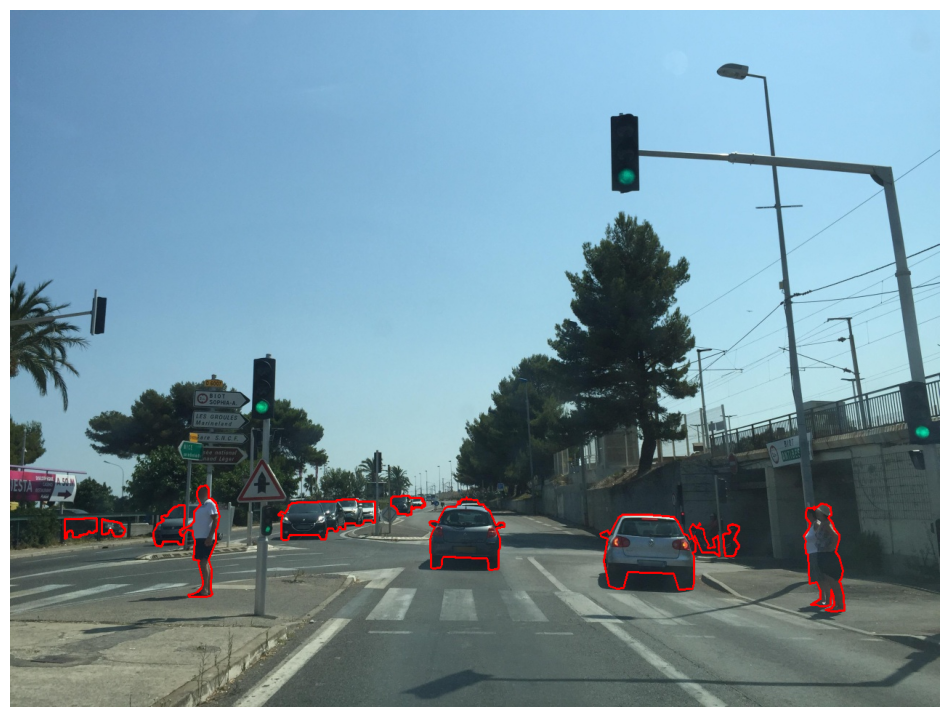

In [29]:
sample_image = glob(
    "/kaggle/working/yolo_dataset/images/train/*.jpg"
)[0]

sample_label = sample_image.replace(
    "/images/",
    "/labels/"
).replace(".jpg", ".txt")

image = cv2.imread(sample_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

with open(sample_label, "r") as f:
    lines = f.readlines()

for line in lines:

    parts = line.strip().split()

    cls = int(parts[0])

    coords = np.array(parts[1:], dtype=np.float32)

    coords[0::2] *= w
    coords[1::2] *= h

    pts = coords.reshape(-1,2).astype(np.int32)

    cv2.polylines(
        image,
        [pts],
        True,
        (255,0,0),
        2
    )

plt.figure(figsize=(12,12))
plt.imshow(image)
plt.axis("off")
plt.show()

In [30]:
yaml_text = """
path: /kaggle/working/yolo_dataset

train: images/train
val: images/val

names:
  0: drivable
  1: person
  2: vehicle
  3: bicycle
"""

with open("/kaggle/working/yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_text)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s-seg.pt")

results = model.train(

    data="/kaggle/working/yolo_dataset/data.yaml",

    epochs=50,

    imgsz=640,

    batch=8,

    device=0,

    workers=4,

    cache=True,

    amp=True,

    overlap_mask=False,

    optimizer="AdamW",

    lr0=1e-3,

    weight_decay=1e-4,

    warmup_epochs=3,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,

    translate=0.1,
    scale=0.3,
    fliplr=0.5,

    mosaic=0.5,

    pretrained=True,

    patience=15
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.